# Experiment I: Basic Data Visualization Techniques

**Dataset:** NBA 2025-26 Season Play-by-Play Data (pbp2026.csv)

**Aim:** To explore basic data visualization techniques such as line chart, bar chart, pie chart, histogram, box plot and scatter plot using Python libraries Pandas, Matplotlib and Seaborn.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


## Step 2: Load Dataset

In [2]:
df = pd.read_csv('pbp2026.csv')
df.head()


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,desc,season
0,22500001,1,PT12M00.00S,0.0,0.0,NaN,0,NaN,period,start,NaN,0.0,0.0,0.0,Start of 1st Period (7:44 PM EST),2026
1,22500001,1,PT12M00.00S,NaN,NaN,OKC,1631096,C. Holmgren,Jump Ball,NaN,NaN,0.0,0.0,0.0,Jump Ball Holmgren vs. Adams: Tip to Thompson,2026
2,22500001,1,PT11M36.00S,NaN,NaN,HOU,1630578,A. Sengun,Missed Shot,Jump Shot,Missed,-179.0,179.0,25.0,MISS Sengun 25' 3PT Jump Shot,2026
3,22500001,1,PT11M31.00S,NaN,NaN,OKC,1641717,C. Wallace,Rebound,Unknown,NaN,0.0,0.0,0.0,Wallace REBOUND (Off:0 Def:1),2026
4,22500001,1,PT11M26.00S,2.0,0.0,OKC,1631096,C. Holmgren,Made Shot,Cutting Layup Shot,Made,0.0,13.0,1.0,Holmgren 1' Cutting Layup Shot (2 PTS) (Dort 1...,2026


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 622189 entries, 0 to 622188
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   gameid    622189 non-null  int64  
 1   period    622189 non-null  int64  
 2   clock     622189 non-null  object 
 3   h_pts     163415 non-null  float64
 4   a_pts     163415 non-null  float64
 5   team      570066 non-null  object 
 6   playerid  622189 non-null  int64  
 7   player    571168 non-null  object 
 8   type      589678 non-null  object 
 9   subtype   522886 non-null  object 
 10  result    219348 non-null  object 
 11  x         620551 non-null  float64
 12  y         620551 non-null  float64
 13  dist      620553 non-null  float64
 14  desc      622189 non-null  object 
 15  season    622189 non-null  int64  
dtypes: float64(5), int64(4), object(7)
memory usage: 76.0+ MB


In [4]:
df.describe()


,gameid,period,h_pts,a_pts,playerid,x,y,dist,season
count,6.221890e+05,622189.000000,163415.000000,163415.000000,6.221890e+05,620551.000000,620551.000000,620553.000000,622189.0
mean,2.250061e+07,2.524849,60.277820,59.283377,9.895619e+07,-0.998476,33.763557,4.520957,2026.0
std,3.561084e+02,1.130129,35.006686,34.518722,3.839974e+08,69.168813,71.949940,8.861332,0.0
min,2.250000e+07,1.000000,0.000000,0.000000,0.000000e+00,-250.000000,-51.000000,0.000000,2026.0
25%,2.250030e+07,2.000000,31.000000,30.000000,1.628404e+06,0.000000,0.000000,0.000000,2026.0
50%,2.250061e+07,3.000000,60.000000,59.000000,1.630534e+06,0.000000,0.000000,0.000000,2026.0
75%,2.250092e+07,4.000000,89.000000,87.000000,1.641750e+06,0.000000,17.000000,3.000000,2026.0
max,2.250123e+07,6.000000,157.000000,157.000000,1.610613e+09,250.000000,734.000000,73.000000,2026.0


## Step 3: Line Chart - Score Progression During a Game

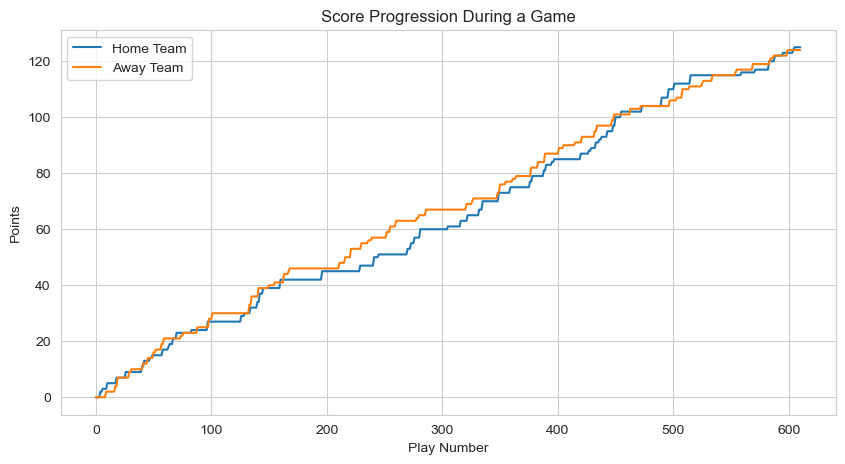

In [5]:
game = df[df['gameid'] == df['gameid'].iloc[0]].copy()
game['h_pts'] = game['h_pts'].ffill().fillna(0)
game['a_pts'] = game['a_pts'].ffill().fillna(0)

plt.figure(figsize=(10,5))
plt.plot(range(len(game)), game['h_pts'], label='Home Team')
plt.plot(range(len(game)), game['a_pts'], label='Away Team')
plt.xlabel('Play Number')
plt.ylabel('Points')
plt.title('Score Progression During a Game')
plt.legend()
plt.show()


## Step 4: Bar Chart - Top 10 Players by Made Shots

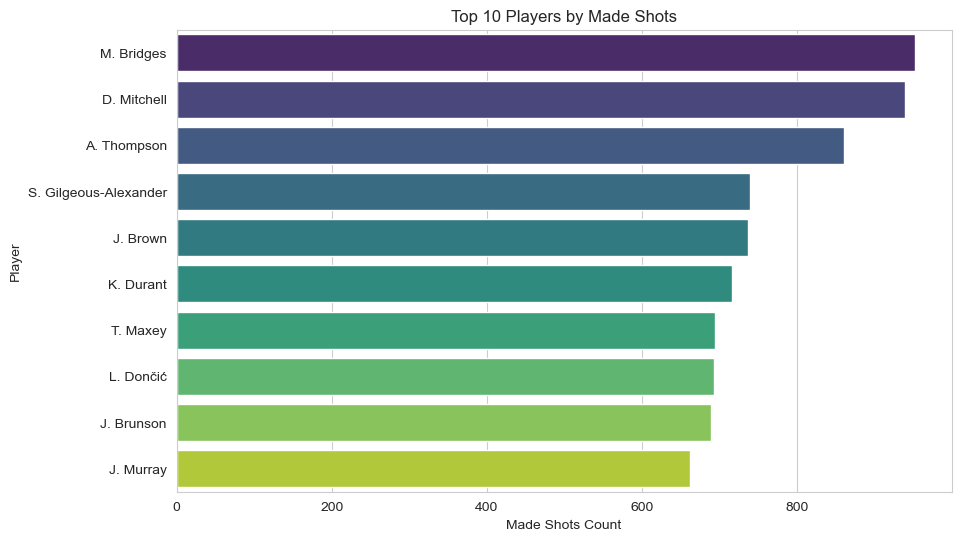

In [6]:
made = df[df['result'] == 'Made']
top_scorers = made.groupby('player').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='viridis')
plt.xlabel('Made Shots Count')
plt.ylabel('Player')
plt.title('Top 10 Players by Made Shots')
plt.show()


## Step 5: Pie Chart - Distribution of Play Event Types

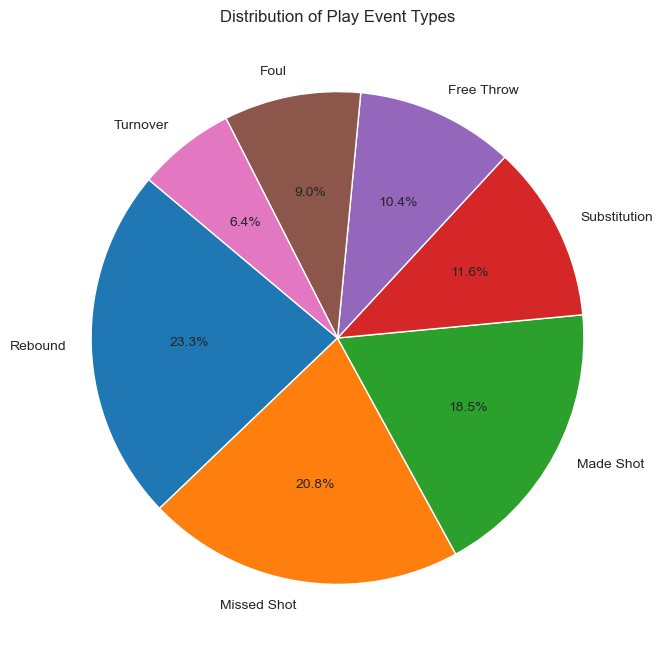

In [7]:
type_counts = df['type'].value_counts().head(7)

plt.figure(figsize=(8,8))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Play Event Types')
plt.show()


## Step 6: Histogram - Distribution of Shot Distances

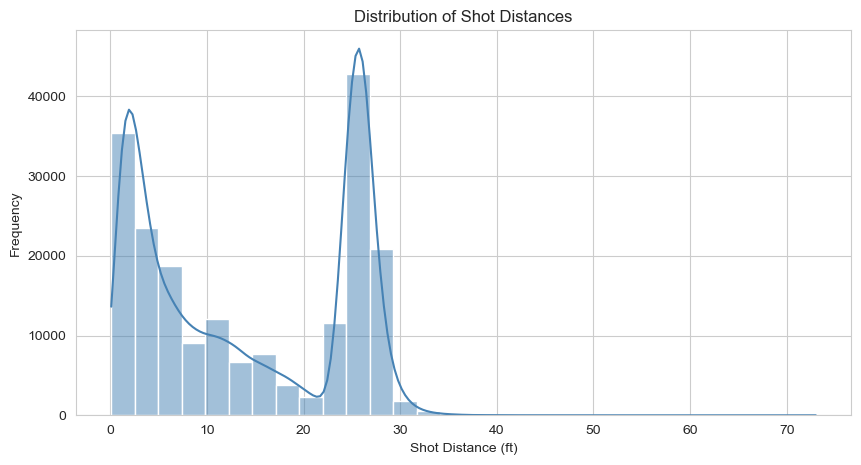

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['dist'] > 0]['dist'], bins=30, kde=True, color='steelblue')
plt.xlabel('Shot Distance (ft)')
plt.ylabel('Frequency')
plt.title('Distribution of Shot Distances')
plt.show()


## Step 7: Box Plot - Shot Distance by Result

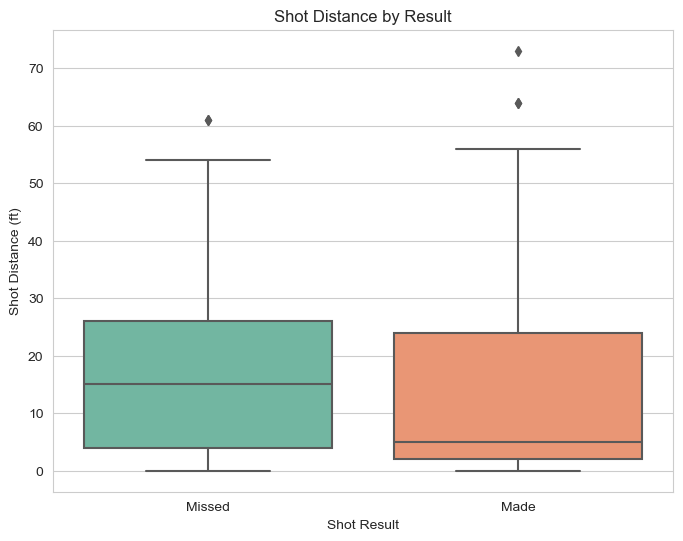

In [9]:
shots = df[df['result'].isin(['Made','Missed'])]

plt.figure(figsize=(8,6))
sns.boxplot(x='result', y='dist', data=shots, palette='Set2')
plt.xlabel('Shot Result')
plt.ylabel('Shot Distance (ft)')
plt.title('Shot Distance by Result')
plt.show()


## Step 8: Scatter Plot - Shot Chart (Made vs Missed)

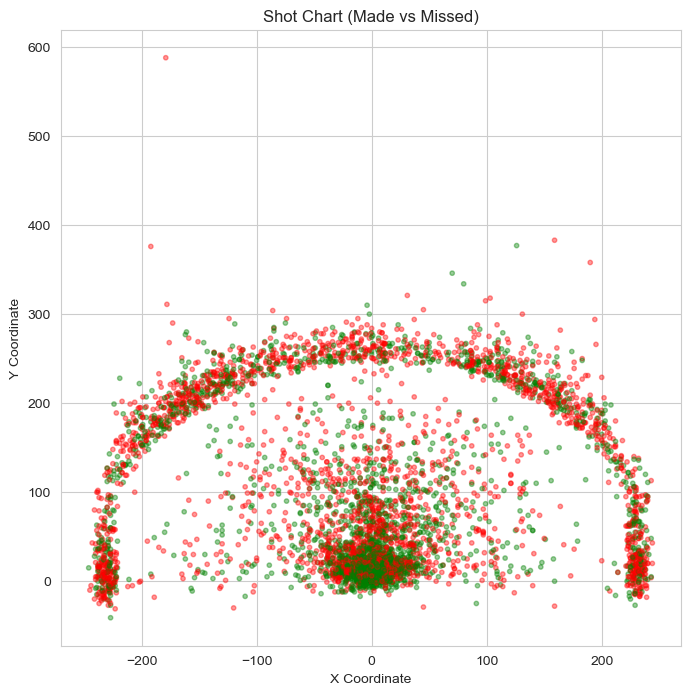

In [10]:
sample = shots.sample(5000, random_state=42)
colors = sample['result'].map({'Made':'green','Missed':'red'})

plt.figure(figsize=(8,8))
plt.scatter(sample['x'], sample['y'], c=colors, alpha=0.4, s=10)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Shot Chart (Made vs Missed)')
plt.show()


## Result

Basic data visualization techniques - line chart, bar chart, pie chart, histogram, box plot and scatter plot - were successfully implemented on the NBA play-by-play dataset using Pandas, Matplotlib and Seaborn.